# Identifikasi Jenis Penyakit Kulit Menggunakan Citra Digital Berbasis Ekstraksi Fitur Local Binary Pattern (LBP) dan Algoritma Random Forest

Notebook ini dibuat untuk alur skripsi dengan tahapan yang terlihat jelas:

1. Pemodelan sistem
2. Pengumpulan dataset
3. Preprocessing data
4. Ekstraksi fitur menggunakan LBP
5. Klasifikasi menggunakan Random Forest dan training model
6. Pengujian model

Dataset dibaca dari folder `finalpenyakitkulit`, dengan struktur satu folder untuk setiap kelas penyakit kulit.


## 1. Pemodelan Sistem

Alur sistem yang digunakan:

**Citra digital penyakit kulit -> preprocessing citra -> ekstraksi fitur LBP -> pembagian data 80:20 -> training Random Forest -> pengujian model -> hasil identifikasi**

Parameter utama:

- Ukuran citra: 224 x 224 piksel
- LBP: `P=8`, `R=1`, metode `uniform`
- Klasifikasi: `RandomForestClassifier`
- Training: 80%
- Testing: 20%
- Pembagian data: stratified, agar proporsi kelas tetap seimbang pada data train dan test


In [1]:
import json
import warnings
from pathlib import Path

import cv2
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from skimage.feature import local_binary_pattern
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
np.random.seed(42)

DATASET_CANDIDATES = [Path('dataset'), Path('finalpenyakitkulit')]
DATASET_DIR = next((path for path in DATASET_CANDIDATES if path.exists()), DATASET_CANDIDATES[-1])
OUTPUT_DIR = Path('output_lbp_random_forest')
MODEL_DIR = OUTPUT_DIR / 'model'
RESULT_DIR = OUTPUT_DIR / 'hasil_pengujian'
FEATURE_DIR = OUTPUT_DIR / 'fitur'

for directory in [OUTPUT_DIR, MODEL_DIR, RESULT_DIR, FEATURE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
RESIZE_TO = (224, 224)
LBP_POINTS = 8
LBP_RADIUS = 1
LBP_METHOD = 'uniform'
RANDOM_STATE = 42

print('Library berhasil di-import dan konfigurasi sistem siap digunakan.')

Library berhasil di-import dan konfigurasi sistem siap digunakan.


## 2. Pengumpulan Dataset

Tahap ini membaca semua citra dari folder dataset. Nama folder digunakan sebagai label kelas.


Kelas penyakit kulit: ['acne', 'alopecia', 'atopic', 'normal', 'psoriasis', 'vitiligo']
Total citra: 6584


,kelas,jumlah_citra
0,acne,1008
1,alopecia,1220
2,atopic,1008
3,normal,1258
4,psoriasis,1008
5,vitiligo,1082


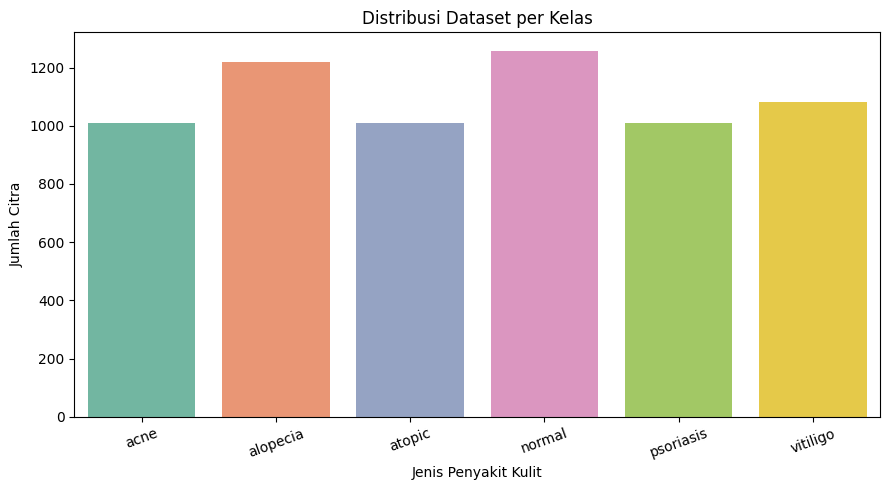

In [2]:
def collect_dataset(dataset_dir):
    records = []
    class_dirs = sorted([p for p in dataset_dir.iterdir() if p.is_dir()])
    for class_dir in class_dirs:
        for image_path in sorted(class_dir.rglob('*')):
            if image_path.is_file() and image_path.suffix.lower() in IMAGE_EXTENSIONS:
                records.append({'path': str(image_path), 'label': class_dir.name})
    return pd.DataFrame(records)

df_dataset = collect_dataset(DATASET_DIR)
class_names = sorted(df_dataset['label'].unique())

print('Kelas penyakit kulit:', class_names)
print('Total citra:', len(df_dataset))
distribution = df_dataset['label'].value_counts().sort_index()
distribution_df = distribution.rename_axis('kelas').reset_index(name='jumlah_citra')
display(distribution_df)

plt.figure(figsize=(9, 5))
sns.barplot(data=distribution_df, x='kelas', y='jumlah_citra', palette='Set2')
plt.title('Distribusi Dataset per Kelas')
plt.xlabel('Jenis Penyakit Kulit')
plt.ylabel('Jumlah Citra')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(RESULT_DIR / 'distribusi_dataset.png', dpi=150)
plt.show()

## 3. Preprocessing Data

Preprocessing dilakukan agar citra memiliki format yang seragam sebelum fitur LBP dihitung:

- Membaca citra dari file
- Resize ke ukuran 224 x 224 piksel
- Konversi BGR ke grayscale
- Gaussian blur ringan untuk mengurangi noise


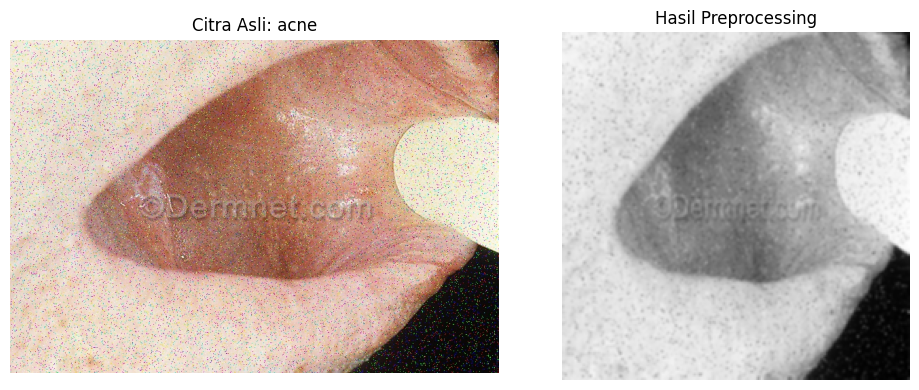

In [3]:
def preprocess_image(image_path, size=RESIZE_TO):
    image = cv2.imread(str(image_path))
    if image is None:
        raise ValueError(f'Gambar gagal dibaca: {image_path}')
    image = cv2.resize(image, size)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (3, 3), 0)
    return gray

sample_row = df_dataset.sample(1, random_state=42).iloc[0]
sample_original = cv2.imread(sample_row['path'])
sample_original_rgb = cv2.cvtColor(sample_original, cv2.COLOR_BGR2RGB)
sample_preprocessed = preprocess_image(sample_row['path'])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(sample_original_rgb)
axes[0].set_title(f"Citra Asli: {sample_row['label']}")
axes[0].axis('off')
axes[1].imshow(sample_preprocessed, cmap='gray')
axes[1].set_title('Hasil Preprocessing')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## 4. Ekstraksi Fitur Menggunakan Local Binary Pattern (LBP)

LBP digunakan untuk mengambil informasi tekstur lokal dari citra grayscale. Hasil LBP kemudian diubah menjadi histogram fitur, sehingga setiap citra direpresentasikan dalam bentuk vektor angka.


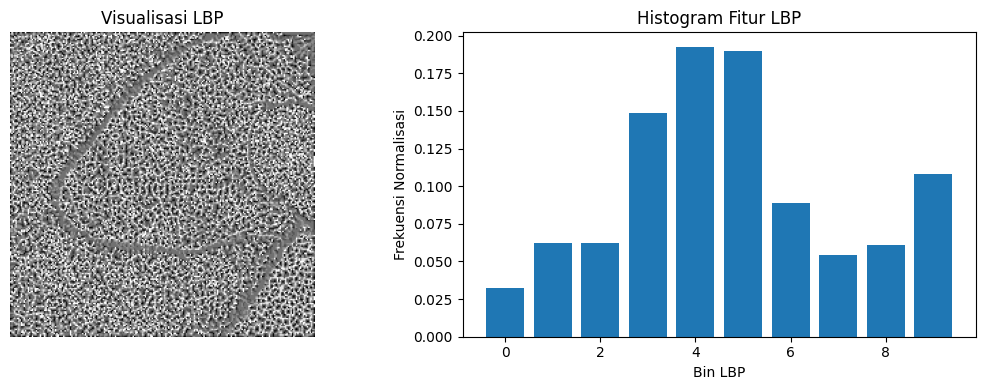

Jumlah fitur LBP per citra: 10


In [4]:
def extract_lbp_features(gray_image, points=LBP_POINTS, radius=LBP_RADIUS, method=LBP_METHOD):
    lbp = local_binary_pattern(gray_image, points, radius, method=method)
    n_bins = points + 2 if method == 'uniform' else 2 ** points
    hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, n_bins + 1), range=(0, n_bins))
    hist = hist.astype('float32')
    hist /= hist.sum() + 1e-7
    return lbp, hist

sample_lbp, sample_hist = extract_lbp_features(sample_preprocessed)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(sample_lbp, cmap='gray')
axes[0].set_title('Visualisasi LBP')
axes[0].axis('off')
axes[1].bar(range(len(sample_hist)), sample_hist)
axes[1].set_title('Histogram Fitur LBP')
axes[1].set_xlabel('Bin LBP')
axes[1].set_ylabel('Frekuensi Normalisasi')
plt.tight_layout()
plt.show()

print('Jumlah fitur LBP per citra:', len(sample_hist))

In [5]:
features = []
labels = []
paths = []
failed_images = []

for row in df_dataset.itertuples(index=False):
    try:
        gray = preprocess_image(row.path)
        _, hist = extract_lbp_features(gray)
        features.append(hist)
        labels.append(row.label)
        paths.append(row.path)
    except Exception as exc:
        failed_images.append({'path': row.path, 'label': row.label, 'error': str(exc)})

X = np.asarray(features)
y = np.asarray(labels)
feature_names = [f'lbp_bin_{i}' for i in range(X.shape[1])]

feature_df = pd.DataFrame(X, columns=feature_names)
feature_df.insert(0, 'path', paths)
feature_df['label'] = y
feature_df.to_csv(FEATURE_DIR / 'fitur_lbp.csv', index=False)

if failed_images:
    pd.DataFrame(failed_images).to_csv(RESULT_DIR / 'gambar_gagal_dibaca.csv', index=False)

print('Jumlah citra berhasil diekstraksi:', len(X))
print('Dimensi fitur:', X.shape)
print('File fitur disimpan ke:', FEATURE_DIR / 'fitur_lbp.csv')
display(feature_df.head())

Jumlah citra berhasil diekstraksi: 6584
Dimensi fitur: (6584, 10)
File fitur disimpan ke: output_lbp_random_forest\fitur\fitur_lbp.csv


,path,lbp_bin_0,lbp_bin_1,lbp_bin_2,lbp_bin_3,lbp_bin_4,lbp_bin_5,lbp_bin_6,lbp_bin_7,lbp_bin_8,lbp_bin_9,label
0,finalpenyakitkulit\acne\07Acne081101.jpg,0.020029,0.048390,0.039840,0.134427,0.214106,0.219328,0.107302,0.061244,0.067801,0.087532,acne
1,finalpenyakitkulit\acne\07AcnePittedScars.jpg,0.032047,0.052037,0.055684,0.144531,0.197545,0.179986,0.111368,0.068818,0.070233,0.087751,acne
2,finalpenyakitkulit\acne\07AcnePittedScars1.jpg,0.033024,0.057856,0.057239,0.147620,0.179588,0.173549,0.114298,0.070910,0.072804,0.093112,acne
3,finalpenyakitkulit\acne\07PerioralDermEye.jpg,0.027164,0.059291,0.046516,0.133072,0.165976,0.174227,0.114098,0.077866,0.091159,0.110631,acne
4,finalpenyakitkulit\acne\07PerioralDermNose.jpg,0.016303,0.041075,0.036492,0.130361,0.262596,0.211217,0.088329,0.053372,0.088090,0.072166,acne


## 5. Pembagian Data Training dan Testing

Dataset dibagi menjadi:

- 80% data training
- 20% data testing

Pembagian menggunakan `stratify=y` agar distribusi setiap kelas tetap proporsional pada data training dan testing.


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.8,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print('Jumlah data training:', len(X_train))
print('Jumlah data testing :', len(X_test))
print('Persentase training :', round(len(X_train) / len(X) * 100, 2), '%')
print('Persentase testing  :', round(len(X_test) / len(X) * 100, 2), '%')

split_df = pd.DataFrame({
    'kelas': class_names,
    'training': [np.sum(y_train == c) for c in class_names],
    'testing': [np.sum(y_test == c) for c in class_names],
})
display(split_df)

Jumlah data training: 5267
Jumlah data testing : 1317
Persentase training : 80.0 %
Persentase testing  : 20.0 %


,kelas,training,testing
0,acne,807,201
1,alopecia,976,244
2,atopic,806,202
3,normal,1006,252
4,psoriasis,806,202
5,vitiligo,866,216


## 6. Klasifikasi Menggunakan Random Forest dan Training Model

Random Forest digunakan karena mampu melakukan klasifikasi multi-kelas dan bekerja baik pada fitur tabular seperti histogram LBP.


In [7]:
model = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    class_weight='balanced',
    n_jobs=-1,
)

model.fit(X_train, y_train)

model_bundle = {
    'model': model,
    'class_names': class_names,
    'feature_names': feature_names,
    'resize_to': RESIZE_TO,
    'lbp_points': LBP_POINTS,
    'lbp_radius': LBP_RADIUS,
    'lbp_method': LBP_METHOD,
}
joblib.dump(model_bundle, MODEL_DIR / 'model_lbp_random_forest.joblib')

print('Training model selesai.')
print('Model disimpan ke:', MODEL_DIR / 'model_lbp_random_forest.joblib')
print('Jumlah pohon Random Forest:', model.n_estimators)

Training model selesai.
Model disimpan ke: output_lbp_random_forest\model\model_lbp_random_forest.joblib
Jumlah pohon Random Forest: 300


## 7. Pengujian Model

Pengujian dilakukan pada data testing 20%. Metrik yang ditampilkan:

- Accuracy
- Precision
- Recall
- F1-score
- Classification report
- Confusion matrix


In [8]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)

metrics = {
    'train_accuracy': float(train_accuracy),
    'test_accuracy': float(test_accuracy),
    'precision_weighted': float(precision),
    'recall_weighted': float(recall),
    'f1_weighted': float(f1),
    'total_data': int(len(X)),
    'training_data': int(len(X_train)),
    'testing_data': int(len(X_test)),
    'classes': class_names,
}

print('Akurasi training:', round(train_accuracy, 4), f'({train_accuracy*100:.2f}%)')
print('Akurasi testing :', round(test_accuracy, 4), f'({test_accuracy*100:.2f}%)')
print('Precision       :', round(precision, 4))
print('Recall          :', round(recall, 4))
print('F1-score        :', round(f1, 4))

Akurasi training: 1.0 (100.00%)
Akurasi testing : 0.8155 (81.55%)
Precision       : 0.8156
Recall          : 0.8155
F1-score        : 0.8144


In [9]:
report_dict = classification_report(y_test, y_test_pred, target_names=class_names, output_dict=True, zero_division=0)
report_text = classification_report(y_test, y_test_pred, target_names=class_names, zero_division=0)
report_df = pd.DataFrame(report_dict).transpose()

report_df.to_csv(RESULT_DIR / 'classification_report.csv')
(RESULT_DIR / 'classification_report.txt').write_text(report_text, encoding='utf-8')
(RESULT_DIR / 'metrics.json').write_text(json.dumps(metrics, indent=2), encoding='utf-8')

display(report_df)
print(report_text)

,precision,recall,f1-score,support
acne,0.775120,0.805970,0.790244,201.00000
alopecia,0.863813,0.909836,0.886228,244.00000
atopic,0.803653,0.871287,0.836105,202.00000
normal,0.800847,0.750000,0.774590,252.00000
psoriasis,0.811594,0.831683,0.821516,202.00000
vitiligo,0.830688,0.726852,0.775309,216.00000
accuracy,0.815490,0.815490,0.815490,0.81549
macro avg,0.814286,0.815938,0.813998,1317.00000
weighted avg,0.815559,0.815490,0.814412,1317.00000


              precision    recall  f1-score   support

        acne       0.78      0.81      0.79       201
    alopecia       0.86      0.91      0.89       244
      atopic       0.80      0.87      0.84       202
      normal       0.80      0.75      0.77       252
   psoriasis       0.81      0.83      0.82       202
    vitiligo       0.83      0.73      0.78       216

    accuracy                           0.82      1317
   macro avg       0.81      0.82      0.81      1317
weighted avg       0.82      0.82      0.81      1317



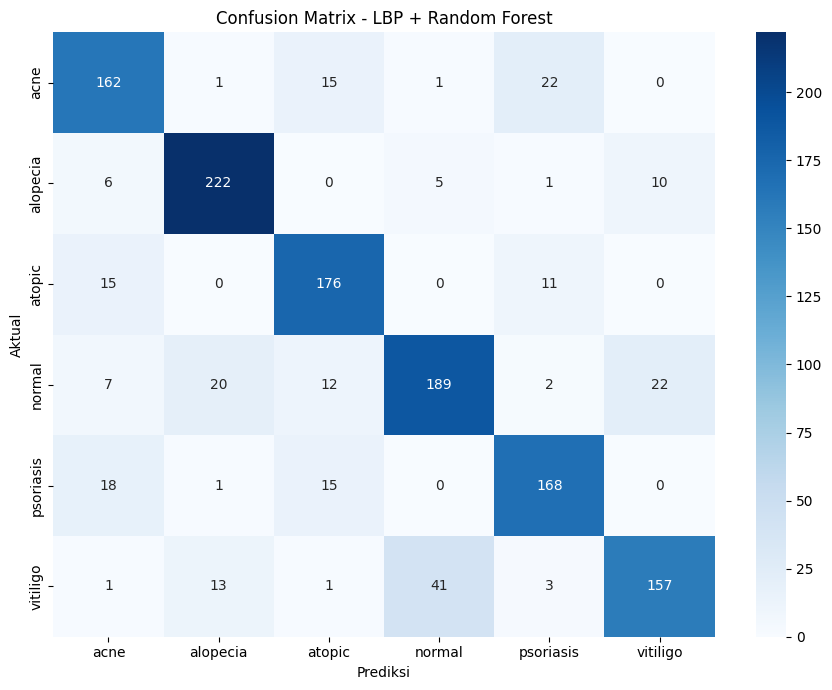

,acne,alopecia,atopic,normal,psoriasis,vitiligo
acne,162,1,15,1,22,0
alopecia,6,222,0,5,1,10
atopic,15,0,176,0,11,0
normal,7,20,12,189,2,22
psoriasis,18,1,15,0,168,0
vitiligo,1,13,1,41,3,157


In [10]:
cm = confusion_matrix(y_test, y_test_pred, labels=class_names)
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
cm_df.to_csv(RESULT_DIR / 'confusion_matrix.csv')

plt.figure(figsize=(9, 7))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - LBP + Random Forest')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.savefig(RESULT_DIR / 'confusion_matrix.png', dpi=150)
plt.show()

display(cm_df)

## 8. Uji Prediksi Satu Citra

Sel ini dapat digunakan untuk menguji satu gambar baru. Ganti nilai `test_image_path` dengan path gambar yang ingin diuji.


In [ ]:
def predict_single_image(image_path):
    gray = preprocess_image(image_path)
    _, hist = extract_lbp_features(gray)
    prediction = model.predict([hist])[0]
    probabilities = model.predict_proba([hist])[0]
    probability_df = pd.DataFrame({
        'kelas': model.classes_,
        'probabilitas': probabilities,
    }).sort_values('probabilitas', ascending=False)
    return prediction, probability_df

# Contoh uji menggunakan satu data testing dari dataset
example_path = df_dataset.sample(1, random_state=7).iloc[0]['path']
prediction, probability_df = predict_single_image(example_path)

image = cv2.imread(example_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(5, 4))
plt.imshow(image)
plt.title(f'Hasil prediksi: {prediction}')
plt.axis('off')
plt.show()

display(probability_df)

## 9. Kesimpulan Hasil Sistem

Sel ini merangkum output utama yang dapat dimasukkan ke pembahasan skripsi.


In [ ]:
summary = pd.DataFrame([
    {'tahap': 'Pengumpulan dataset', 'hasil': f'{len(df_dataset)} citra dari {len(class_names)} kelas'},
    {'tahap': 'Preprocessing data', 'hasil': f'Resize {RESIZE_TO[0]}x{RESIZE_TO[1]}, grayscale, Gaussian blur'},
    {'tahap': 'Ekstraksi fitur LBP', 'hasil': f'{X.shape[1]} fitur per citra'},
    {'tahap': 'Training model', 'hasil': f'{len(X_train)} data training dengan Random Forest'},
    {'tahap': 'Pengujian model', 'hasil': f'{len(X_test)} data testing, akurasi {test_accuracy*100:.2f}%'},
])
display(summary)
print('Semua output tersimpan di folder:', OUTPUT_DIR)